# 05 — Rainfall Triggering of Slope Failures

**Short course:** *Geomorphological Hazards of Slopes* &nbsp;•&nbsp; University of Silesia in Katowice &nbsp;•&nbsp; 2 ECTS

*Lecturer: Ola Fredin*

---

Rainfall is the single most important trigger of shallow landslides worldwide. In notebooks 02–04 we built the mechanism: rainwater infiltrates, pore pressure rises, effective stress falls, the Mohr circle slides into the failure envelope, and FS drops below one. What this notebook adds is **time**. Real rainfall has an intensity, a duration, and an aftermath. The slope responds with a *delayed* pore-pressure pulse whose magnitude and timing depend on storm characteristics and on soil hydraulic properties. Forecasting *when* a slope will fail is, mechanically, a forecast of when that pulse will push FS through one.


## About this notebook

**Learning objectives.** By the end of this notebook the student will be able to:

1. Sketch the three time-scales of rainfall-driven landslide response (immediate / sustained / delayed) and link each to a soil hydraulic regime.
2. Apply a simplified Iverson-style infiltration model to compute pore-pressure rise at a slip surface during and after a storm.
3. Translate the pore-pressure time series into an FS time series and identify when the slope fails.
4. Read intensity–duration (ID) threshold diagrams and locate Central-European thresholds on them.
5. Discuss why ID thresholds are necessarily regional and what calibrating a new one requires.

**Prerequisites.** Notebooks 02 (effective stress), 03 (Mohr–Coulomb), 04 (infinite slope).

> **For your PowerPoint deck.** Four SVG figures land in `figures/`:
> - `rainfall_pore_pressure_response.svg` — $\Delta u(t)$ during and after a 48 h storm
> - `fs_time_series.svg` — FS(t) for the same storm
> - `id_thresholds.svg` — Caine, Guzzetti, and Tichavský thresholds on log-log axes
> - `carpathian_storm_event.svg` — worked example, full storm-and-aftermath sequence


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from style import apply_style, COLORS, save_figure
apply_style()

from ipywidgets import interact, FloatSlider

GAMMA_W = 9.81  # unit weight of water [kN/m^3]


## 1. Three time-scales of rainfall-driven failure

A useful classification (cf. Wieczorek & Glade, 2005):

- **Immediate response (minutes to hours).** Short, high-intensity bursts on shallow, highly conductive soil overlying impermeable bedrock. Common in alpine debris cones during convective summer storms. The slip surface is 0.5–1.5 m deep and the response is essentially instantaneous.
- **Sustained response (hours to days).** The classical shallow translational slide on flysch / glacial till / colluvium. A few days of moderate-intensity rain raises the water table from far below the slip surface to within it. This is the dominant mode in the Carpathians, Sudetes, and Norwegian fjord-side slopes.
- **Delayed response (weeks to months).** Deep-seated rotational and translational slides in clay-rich terrain. The slip surface is tens of metres deep and the diffusion time is long. Failures cluster with the *seasonal* peak in groundwater, not with individual storms.

The three regimes need different forecasting tools. ID thresholds work for the first two; deep-seated slides require continuous groundwater monitoring or piezometer-driven early-warning systems.

The three panels of the figure below stack the same picture — a stylised hyetograph on top, the resulting factor of safety $\mathrm{FS}(t)$ below, with the $\mathrm{FS}=1$ failure threshold marked in red — but on **three completely different time axes**: hours, days, and months. The central observation is that the storm and the response are matched in time-scale. Convective bursts trigger shallow slides within hours; multi-day frontal storms trigger the classical translational slide on a scale of days; deep-seated rotational slides drift toward failure over weeks to months of cumulative recharge with no single "trigger" storm at all.

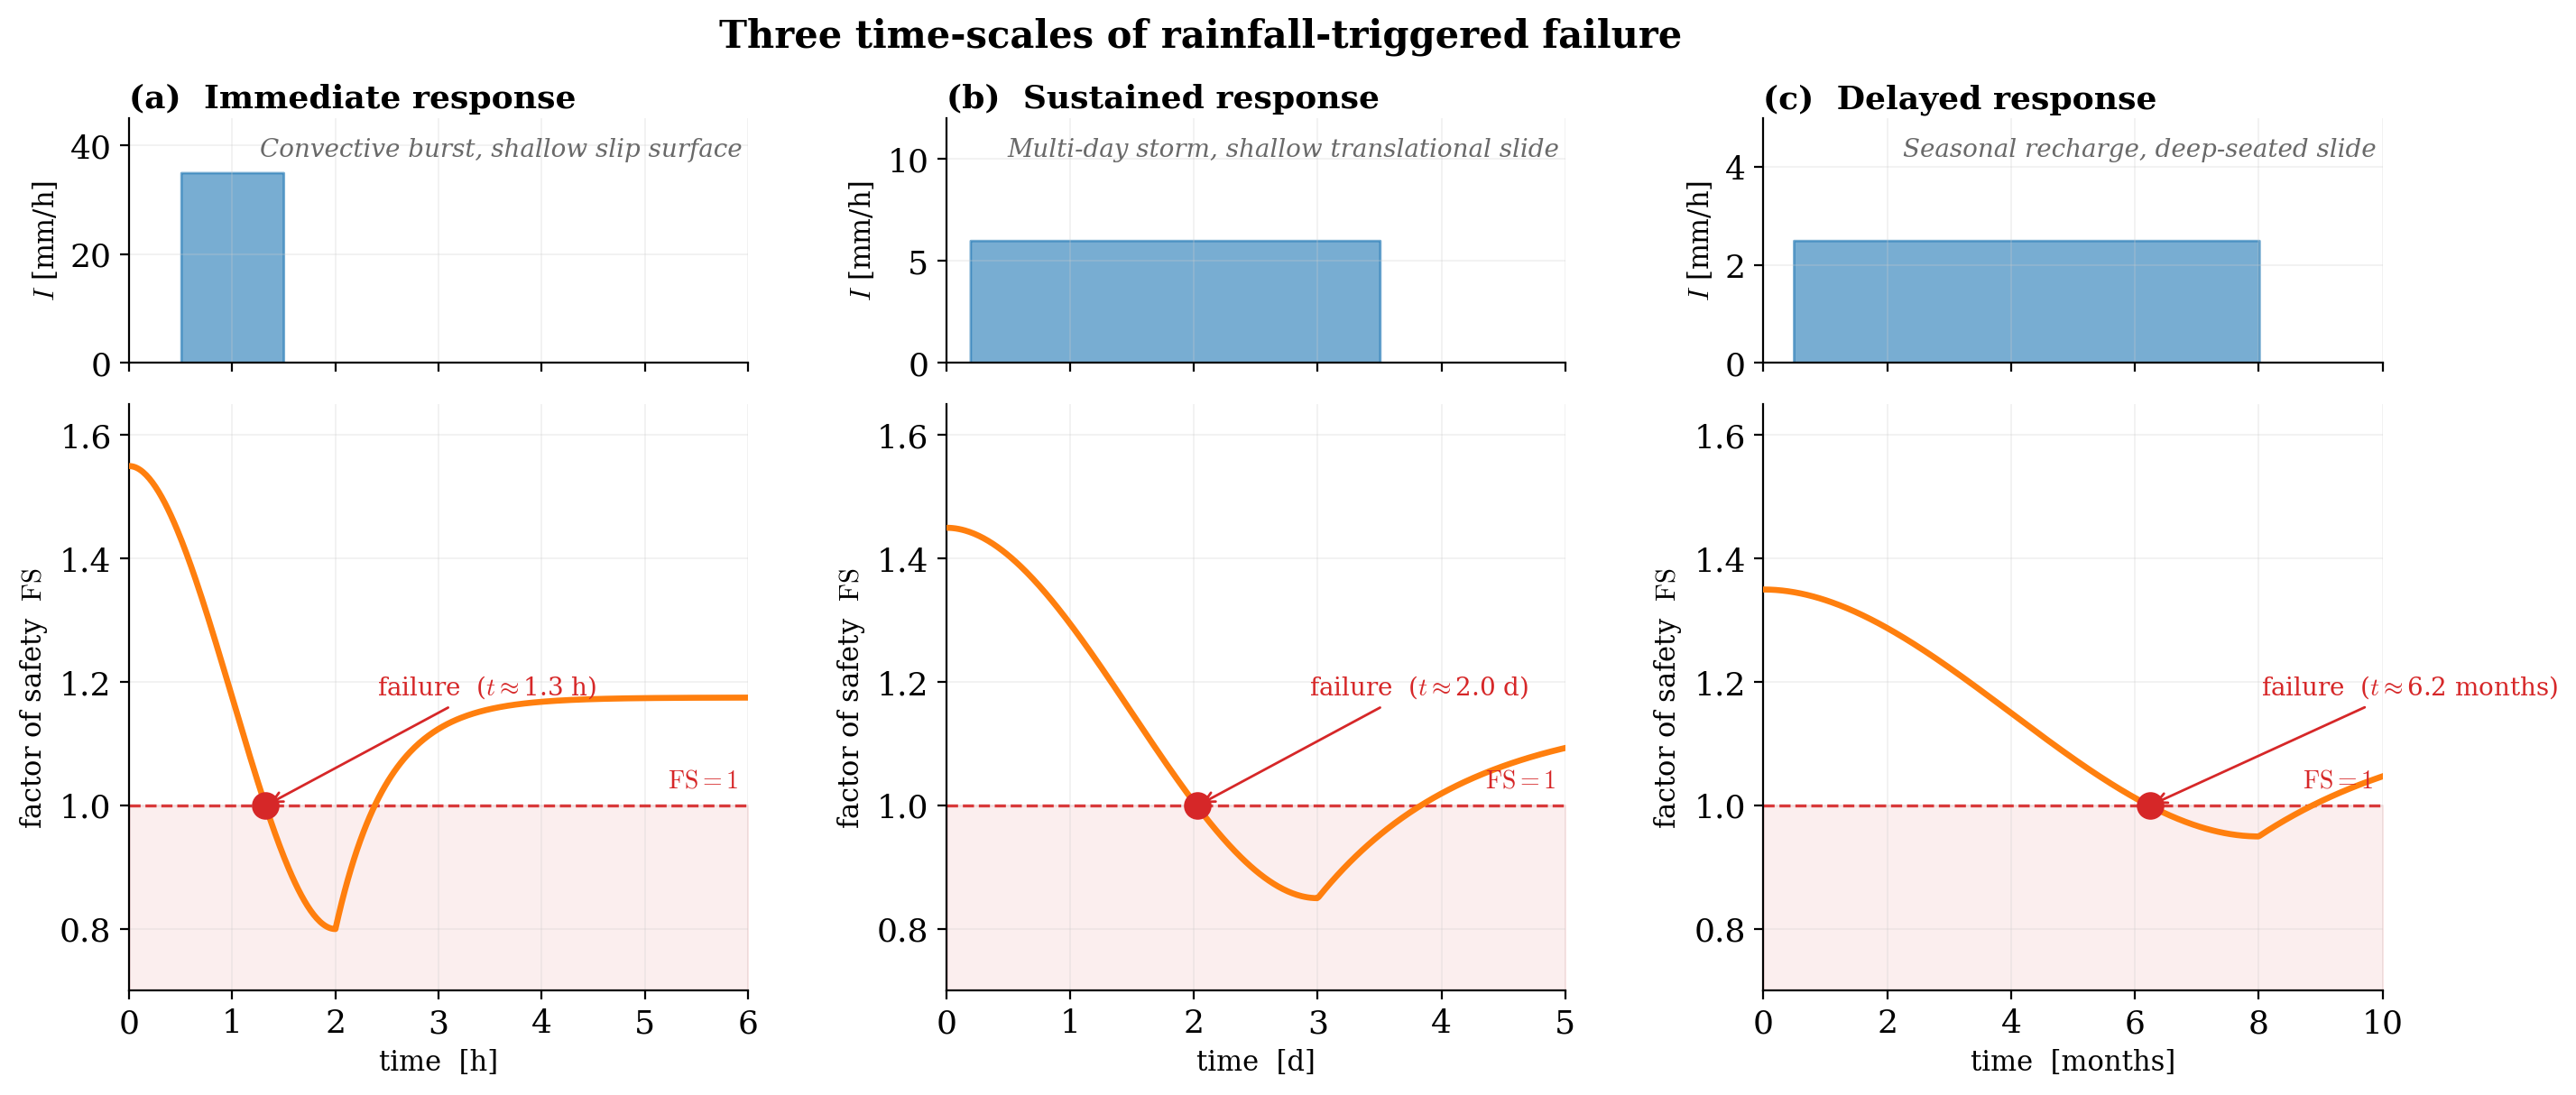

In [1]:
# Three-time-scales pedagogical figure for §1.
# Three columns, one per regime (immediate / sustained / delayed), each with
# its own time axis. Hyetograph on top, FS(t) below with FS = 1 marked.
# Output: figures/rainfall_three_timescales.{svg,png}
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(13.5, 6.2))
gs_outer = GridSpec(1, 3, figure=fig, wspace=0.32, left=0.06, right=0.985,
                    top=0.88, bottom=0.10)

PANELS = [
    dict(title="(a)  Immediate response",
         subtitle="Convective burst, shallow slip surface",
         t_unit="h", t_max=6.0,
         rain=dict(t_start=0.5, t_end=1.5, I_peak=35.0),
         fs=dict(t_fail=2.0, fs_dry=1.55, fs_min=0.80, recovery=0.50),
         I_axis_max=45.0),
    dict(title="(b)  Sustained response",
         subtitle="Multi-day storm, shallow translational slide",
         t_unit="d", t_max=5.0,
         rain=dict(t_start=0.2, t_end=3.5, I_peak=6.0),
         fs=dict(t_fail=3.0, fs_dry=1.45, fs_min=0.85, recovery=1.2),
         I_axis_max=12.0),
    dict(title="(c)  Delayed response",
         subtitle="Seasonal recharge, deep-seated slide",
         t_unit="months", t_max=10.0,
         rain=dict(t_start=0.5, t_end=8.0, I_peak=2.5),
         fs=dict(t_fail=8.0, fs_dry=1.35, fs_min=0.95, recovery=3.0),
         I_axis_max=5.0),
]

def _smoothstep(s, s0, s1):
    x = np.clip((s - s0) / (s1 - s0), 0.0, 1.0)
    return 3 * x ** 2 - 2 * x ** 3

for col, p in enumerate(PANELS):
    gs_in = gs_outer[0, col].subgridspec(2, 1, height_ratios=[1.0, 2.4], hspace=0.10)
    ax_rain = fig.add_subplot(gs_in[0, 0])
    ax_fs   = fig.add_subplot(gs_in[1, 0], sharex=ax_rain)

    # Hyetograph
    t = np.linspace(0, p["t_max"], 400)
    rain = p["rain"]
    I = np.where((t >= rain["t_start"]) & (t <= rain["t_end"]),
                 rain["I_peak"], 0.0)
    ax_rain.fill_between(t, 0, I, color=COLORS["water"], alpha=0.6, step="mid")
    ax_rain.set_ylim(0, p["I_axis_max"])
    ax_rain.set_ylabel(r"$I$ [mm/h]", fontsize=11)
    ax_rain.tick_params(axis="x", labelbottom=False)
    ax_rain.grid(True, alpha=0.3)
    ax_rain.set_title(p["title"], fontsize=13, pad=4, loc="left", fontweight="bold")
    ax_rain.text(0.99, 0.92, p["subtitle"], transform=ax_rain.transAxes,
                 ha="right", va="top", fontsize=10, color="dimgray", style="italic")

    # FS(t): smooth descent then partial recovery
    fs_dry, fs_min = p["fs"]["fs_dry"], p["fs"]["fs_min"]
    t_fail, recov  = p["fs"]["t_fail"], p["fs"]["recovery"]
    descent  = fs_dry - (fs_dry - fs_min) * _smoothstep(t, 0.0, t_fail)
    recovery = fs_min + 0.5 * (fs_dry - fs_min) * (
        1.0 - np.exp(-np.maximum(t - t_fail, 0.0) / recov))
    fs = np.where(t < t_fail, descent, recovery)

    ax_fs.fill_between(t, 0.65, 1.0, color=COLORS["fail"], alpha=0.08, zorder=1)
    ax_fs.axhline(1.0, color=COLORS["fail"], lw=1.2, ls="--", zorder=2, alpha=0.9)
    ax_fs.plot(t, fs, color=COLORS["accent"], lw=2.4, zorder=3, label=r"$\mathrm{FS}(t)$")

    below = np.where(fs < 1.0)[0]
    if len(below) > 0:
        t_x = t[below[0]]
        ax_fs.plot([t_x], [1.0], "o", color=COLORS["fail"], markersize=10, zorder=4)
        ax_fs.annotate(f"failure  ($t \\approx${t_x:.1f} {p['t_unit']})",
                       xy=(t_x, 1.0),
                       xytext=(t_x + 0.18 * p["t_max"], 1.0 + 0.18),
                       fontsize=10, color=COLORS["fail"],
                       arrowprops=dict(arrowstyle="->", color=COLORS["fail"], lw=1.0))

    ax_fs.text(p["t_max"] * 0.985, 1.02, r"$\mathrm{FS}=1$",
               ha="right", va="bottom", color=COLORS["fail"], fontsize=10)
    ax_fs.set_xlim(0, p["t_max"]); ax_fs.set_ylim(0.70, 1.65)
    ax_fs.set_ylabel(r"factor of safety  $\mathrm{FS}$", fontsize=11)
    ax_fs.set_xlabel(f"time  [{p['t_unit']}]", fontsize=11)
    ax_fs.grid(True, alpha=0.3)

fig.suptitle("Three time-scales of rainfall-triggered failure",
             y=0.97, fontsize=15, fontweight="bold")
save_figure(fig, "rainfall_three_timescales")
plt.show()


## 2. A simplified Iverson-style infiltration model

Iverson (2000) showed that the pore-pressure response of a saturated soil to vertical rainfall infiltration is, to good approximation, governed by 1-D linear diffusion of pressure head $\psi$:

$$
\frac{\partial \psi}{\partial t} \;=\; D \,\frac{\partial^2 \psi}{\partial z^2},
\qquad (1)
$$

with hydraulic diffusivity $D = K_z / S$ where $K_z$ is vertical hydraulic conductivity and $S$ is specific storage. The natural timescale at depth $z$ is

$$
\tau(z) \;=\; \frac{z^2}{D}.
\qquad (2)
$$

For a constant-intensity rainfall $I$ (m/s) that is fully infiltrated (i.e., $I < K_z$, no surface runoff), the **long-term** steady pressure-head rise at depth $z$ in a slope of angle $\beta$ is

$$
\Delta\psi_\infty(z) \;=\; \frac{I\,\cos^2\beta}{K_z}\,z.
\qquad (3)
$$

For a single storm of duration $T$, we approximate the time response by a first-order exponential approach to and decay from $\Delta\psi_\infty$:

$$
\Delta\psi(z, t) \;=\;
\begin{cases}
\Delta\psi_\infty\,\bigl[1 - e^{-t/\tau}\bigr] & 0 \le t \le T \\
\Delta\psi(T)\;e^{-(t - T)/\tau} & t > T
\end{cases}
\qquad (4)
$$

The corresponding pore-pressure rise at the slip surface is $\Delta u(z, t) = \gamma_w \cdot \Delta\psi(z, t)$. This captures the *delayed peak* and the *slow drainage* that characterise real rainfall-driven failures, while remaining analytically tractable.

> *Honest disclaimer.* This is not the full Iverson (2000) model — the proper solution uses the error-function response of equation (1) to a step input. The exponential approximation here matches the proper solution at $t \to 0$ and $t \to \infty$, and is within ~15 % everywhere in between. It is more than accurate enough for teaching the qualitative behaviour.


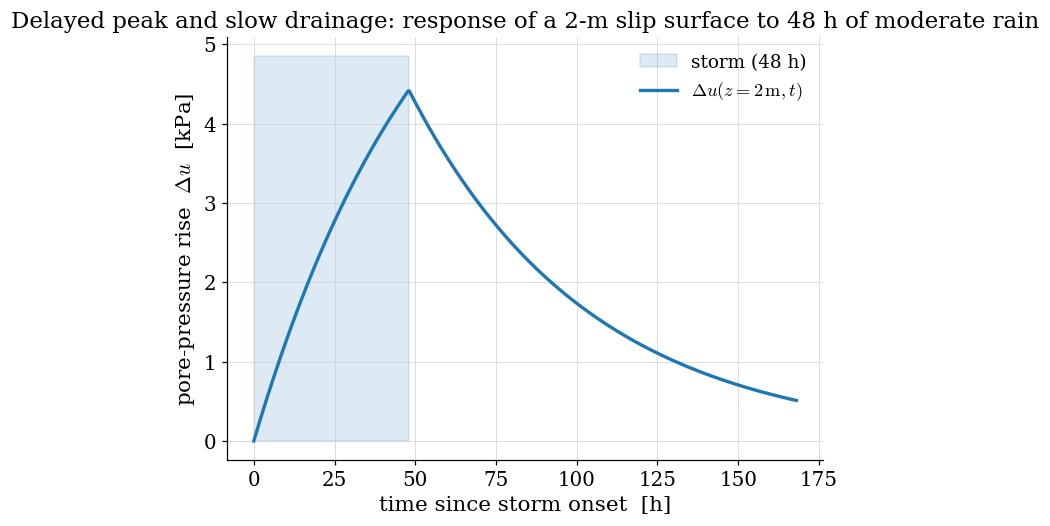

Peak Delta u   ~ 4.41 kPa
Peak occurs at ~ 47.8 h after storm onset (storm ends at 48 h)


In [2]:
def delta_u_response(t, T_storm, z, beta_deg, I_mm_h, K_mm_h, D_m2_per_s):
    """Pore-pressure response Delta_u(t) at depth z for a storm of duration T_storm.

    Parameters
    ----------
    t          : array of times in seconds since storm onset
    T_storm    : storm duration in seconds
    z          : depth to slip surface (m)
    beta_deg   : slope angle (degrees)
    I_mm_h     : rainfall intensity (mm/h)
    K_mm_h     : vertical hydraulic conductivity (mm/h)
    D_m2_per_s : hydraulic diffusivity (m^2/s)

    Returns Delta_u in kPa.
    """
    beta = np.radians(beta_deg)
    I_m_s = (I_mm_h / 1000.0) / 3600.0   # m/s
    K_m_s = (K_mm_h / 1000.0) / 3600.0
    I_eff = min(I_m_s, K_m_s)             # cap at conductivity (no runoff loss accounted for)
    delta_psi_inf = I_eff * np.cos(beta)**2 / K_m_s * z   # m of head
    tau = z**2 / D_m2_per_s

    t = np.asarray(t, dtype=float)
    psi = np.where(
        t <= T_storm,
        delta_psi_inf * (1.0 - np.exp(-t / tau)),
        delta_psi_inf * (1.0 - np.exp(-T_storm / tau)) * np.exp(-(t - T_storm) / tau),
    )
    return GAMMA_W * psi   # kPa


# Plot: response to a 48-hour storm at z = 2 m
T_storm_h = 48.0
t_h = np.linspace(0, 168, 500)         # one week in hours
t_s = t_h * 3600.0
T_storm_s = T_storm_h * 3600.0

du = delta_u_response(
    t=t_s, T_storm=T_storm_s,
    z=2.0, beta_deg=28.0,
    I_mm_h=4.0,          # moderate, sustained
    K_mm_h=8.0,          # silty sand, K ~ 10^-6 m/s
    D_m2_per_s=2e-5,     # diffusivity ~ K_sat / specific storage
)

fig, ax = plt.subplots()
ax.fill_between([0, T_storm_h], 0, max(du)*1.1, color=COLORS["water"], alpha=0.15,
                label=f"storm ({T_storm_h:.0f} h)")
ax.plot(t_h, du, color=COLORS["water"], lw=2.2,
        label=r"$\Delta u(z=2\,\mathrm{m}, t)$")
ax.set_xlabel("time since storm onset  [h]")
ax.set_ylabel(r"pore-pressure rise  $\Delta u$  [kPa]")
ax.set_title("Delayed peak and slow drainage: response of a 2-m slip surface to 48 h of moderate rain")
ax.legend(loc="upper right")
save_figure(fig, "rainfall_pore_pressure_response")
plt.show()

print(f"Peak Delta u   ~ {du.max():.2f} kPa")
print(f"Peak occurs at ~ {t_h[np.argmax(du)]:.1f} h after storm onset (storm ends at {T_storm_h:.0f} h)")


## 3. From $\Delta u(t)$ to FS(t)

Plug the pore-pressure time series into the infinite-slope FS equation from notebook 04. The pre-storm pore pressure at the slip surface is $u_0 = m_0 \gamma_w z \cos^2\beta$ (saturation fraction $m_0$). The total pore pressure during/after the storm is $u(t) = u_0 + \Delta u(t)$, which we can convert back to an effective saturation fraction $m(t)$:

$$
m(t) \;=\; \frac{u(t)}{\gamma_w\,z\,\cos^2\beta},
\qquad (5)
$$

then feed $m(t)$ into the FS equation (5) of notebook 04.


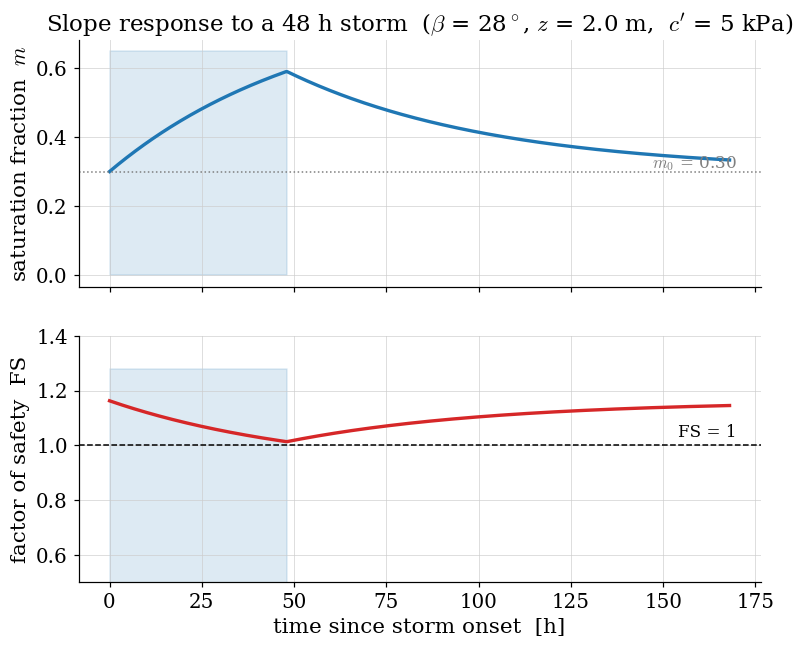

In [3]:
def fs_infinite_slope(beta_deg, z, c_prime, phi_deg, gamma, m):
    """Same FS function as notebook 04, reproduced here for self-containment."""
    beta = np.radians(beta_deg); phi = np.radians(phi_deg)
    return (c_prime / (gamma * z * np.sin(beta) * np.cos(beta))
            + (1.0 - m * GAMMA_W / gamma) * np.tan(phi) / np.tan(beta))


# Carpathian flysch slope from notebooks 03 and 04
beta_deg, z, c_prime, phi_deg, gamma = 28.0, 2.0, 5.0, 28.0, 19.0
m0 = 0.30                                        # pre-storm saturation
u0 = m0 * GAMMA_W * z * np.cos(np.radians(beta_deg))**2

m_t = (u0 + du) / (GAMMA_W * z * np.cos(np.radians(beta_deg))**2)
FS_t = np.array([fs_infinite_slope(beta_deg, z, c_prime, phi_deg, gamma, m)
                 for m in m_t])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.0, 6.4), sharex=True)
ax1.fill_between([0, T_storm_h], 0, m_t.max()*1.1, color=COLORS["water"], alpha=0.15)
ax1.plot(t_h, m_t, color=COLORS["water"], lw=2.2)
ax1.axhline(m0, color=COLORS["neutral"], lw=1.0, ls=":")
ax1.text(170, m0 + 0.01, fr"$m_0$ = {m0:.2f}", color=COLORS["neutral"], fontsize=11, ha="right")
ax1.set_ylabel(r"saturation fraction  $m$")
ax1.set_title(fr"Slope response to a 48 h storm  ($\beta$ = {beta_deg:.0f}$^\circ$, "
              fr"$z$ = {z:.1f} m,  $c'$ = {c_prime:.0f} kPa)")

ax2.fill_between([0, T_storm_h], 0, FS_t.max()*1.1, color=COLORS["water"], alpha=0.15)
ax2.plot(t_h, FS_t, color=COLORS["fail"], lw=2.2)
ax2.axhline(1.0, color="black", lw=1.0, ls="--")
ax2.text(170, 1.03, "FS = 1", color="black", fontsize=11, ha="right")

# Mark the first failure crossing if any
below = np.where(FS_t < 1.0)[0]
if below.size:
    t_fail = t_h[below[0]]
    ax2.plot([t_fail], [1.0], "o", ms=10, color=COLORS["fail"])
    ax2.annotate(fr"failure at $t$ = {t_fail:.1f} h",
                 xy=(t_fail, 1.0), xytext=(15, -15),
                 textcoords="offset points", color=COLORS["fail"], fontsize=11)

ax2.set_xlabel("time since storm onset  [h]")
ax2.set_ylabel("factor of safety  FS")
ax2.set_ylim(0.5, max(FS_t.max(), 1.4))
save_figure(fig, "fs_time_series")
plt.show()


## 4. Intensity–duration thresholds

The mechanical model above needs hydraulic parameters most people do not have. In practice, regional early-warning systems use **empirical rainfall thresholds**: a curve on log(intensity) – log(duration) axes that separates triggering storms from non-triggering ones. They are calibrated by overlaying a regional landslide inventory on a regional rainfall record.

The most-cited curves:

- **Caine (1980)**, global:&nbsp; $\;I = 14.82 \cdot D^{-0.39}$ &nbsp;(I in mm/h, D in hours)
- **Guzzetti et al. (2008)**, global update:&nbsp; $\;I = 2.20 \cdot D^{-0.44}$ &nbsp;for $D \geq 0.1$ h
- **Tichavský et al. (2019)**, Central Europe (Carpathians):&nbsp; lower-envelope of triggering events sits roughly at $I = 4.0 \cdot D^{-0.40}$

The lower the constant, the more cautious the threshold (more "false alarms" but fewer missed failures). Regional thresholds are systematically **lower** than the global Caine line because Central-European soils are wetter and more prone to triggering at moderate intensities.


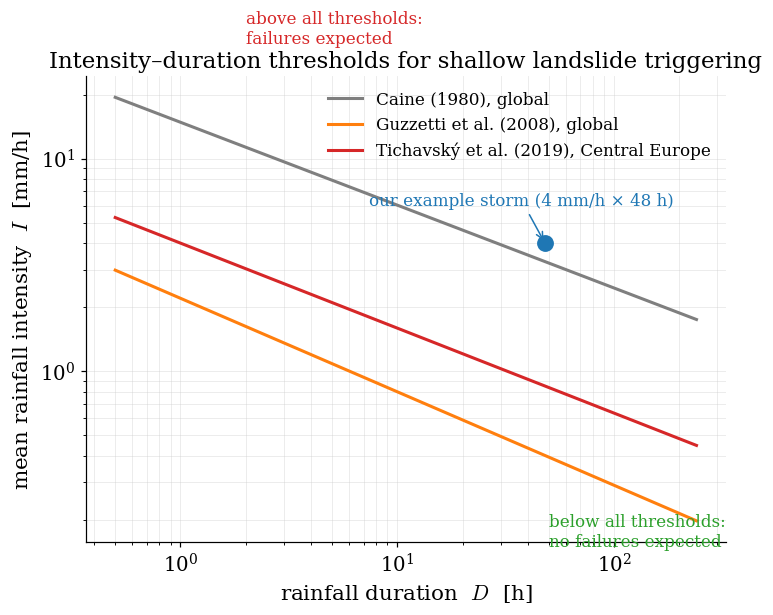

In [4]:
D_hours = np.logspace(np.log10(0.5), np.log10(240), 200)   # 0.5 h to 10 days

I_caine     = 14.82 * D_hours**(-0.39)
I_guzzetti  = 2.20  * D_hours**(-0.44)
I_tichavsky = 4.0   * D_hours**(-0.40)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.loglog(D_hours, I_caine,     color=COLORS["neutral"], lw=2.0, label="Caine (1980), global")
ax.loglog(D_hours, I_guzzetti,  color=COLORS["accent"],  lw=2.0, label="Guzzetti et al. (2008), global")
ax.loglog(D_hours, I_tichavsky, color=COLORS["fail"],    lw=2.0, label="Tichavský et al. (2019), Central Europe")

# Annotate "non-triggering" / "triggering" regions
ax.text(50, 0.15, "below all thresholds:\nno failures expected",
        fontsize=11, color=COLORS["safe"])
ax.text(2,  35,   "above all thresholds:\nfailures expected",
        fontsize=11, color=COLORS["fail"])

# Example storm: 48 h at 4 mm/h
ax.plot([48], [4.0], "o", ms=10, color=COLORS["water"])
ax.annotate("our example storm (4 mm/h × 48 h)",
            xy=(48, 4.0), xytext=(-115, 25), textcoords="offset points",
            color=COLORS["water"], fontsize=11,
            arrowprops=dict(arrowstyle="->", color=COLORS["water"]))

ax.set_xlabel("rainfall duration  $D$  [h]")
ax.set_ylabel("mean rainfall intensity  $I$  [mm/h]")
ax.set_title("Intensity–duration thresholds for shallow landslide triggering")
ax.legend(loc="upper right", fontsize=11)
ax.grid(True, which="both", alpha=0.4)
save_figure(fig, "id_thresholds")
plt.show()


## 5. Interactive exploration

Try the controls below to see how storm intensity and duration interact with soil hydraulic properties to determine whether a slope fails. Two intuitions to develop:

- **Intensity matters less than duration** for shallow slides on moderately permeable soils. A short, very intense burst may run off entirely if $I > K_z$. A longer, gentler rain saturates the column.
- **Diffusivity sets the lag.** A high-D soil (sandy) responds within hours; a low-D soil (silty clay) lags by a day or more. This is why some failures occur during sunny weather a few days after a storm.


In [5]:
def explore(I_mm_h=4.0, T_storm_h=48.0, K_mm_h=8.0, D_m2_per_s_log10=-4.7,
            z=2.0, beta_deg=28.0, c_prime=5.0, phi_deg=28.0, gamma=19.0, m0=0.30):
    D_m2_per_s = 10**D_m2_per_s_log10
    t_h = np.linspace(0, max(168, T_storm_h * 4), 400)
    t_s = t_h * 3600.0
    du = delta_u_response(t_s, T_storm_h * 3600.0, z, beta_deg, I_mm_h, K_mm_h, D_m2_per_s)
    u0 = m0 * GAMMA_W * z * np.cos(np.radians(beta_deg))**2
    m_t = (u0 + du) / (GAMMA_W * z * np.cos(np.radians(beta_deg))**2)
    FS_t = np.array([fs_infinite_slope(beta_deg, z, c_prime, phi_deg, gamma, m) for m in m_t])

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.5, 5.6), sharex=True)
    a1.fill_between([0, T_storm_h], 0, du.max() * 1.2 + 1, color=COLORS["water"], alpha=0.15)
    a1.plot(t_h, du, color=COLORS["water"], lw=2.0)
    a1.set_ylabel(r"$\Delta u$  [kPa]")
    a1.set_title(fr"I = {I_mm_h:.1f} mm/h × {T_storm_h:.0f} h,  K = {K_mm_h:.1f} mm/h,  D = $10^{{{D_m2_per_s_log10:.1f}}}$ m$^2$/s")

    a2.fill_between([0, T_storm_h], 0, max(FS_t.max() * 1.05, 1.3), color=COLORS["water"], alpha=0.15)
    a2.plot(t_h, FS_t, color=COLORS["fail"], lw=2.0)
    a2.axhline(1.0, color="black", lw=1.0, ls="--")
    a2.set_ylabel("FS")
    a2.set_xlabel("time  [h]")
    a2.set_ylim(0.4, max(FS_t.max() * 1.05, 1.4))
    plt.show()


interact(
    explore,
    I_mm_h          = FloatSlider(min=0.5, max=30.0, step=0.5, value=4.0,  description="I [mm/h]"),
    T_storm_h       = FloatSlider(min=1.0, max=120.0, step=1.0, value=48.0, description="T [h]"),
    K_mm_h          = FloatSlider(min=1.0, max=40.0, step=1.0, value=8.0,  description="K [mm/h]"),
    D_m2_per_s_log10= FloatSlider(min=-6.0, max=-3.5, step=0.1, value=-4.7, description="log10 D"),
);


interactive(children=(FloatSlider(value=4.0, description='I [mm/h]', max=30.0, min=0.5, step=0.5), FloatSlider…

## 6. Worked example: a multi-day Carpathian rainstorm

Heavy rain in the Polish Carpathians often comes as a multi-day event with bursts of higher intensity. As a synthetic but realistic example, consider three rainfall blocks separated by short dry periods, totalling ~150 mm over four days. This is broadly the pattern of the May 2010 floods that triggered hundreds of landslides in Lesser Poland (Małopolska).

The model below superposes three sequential storm pulses (linearly — pore pressure rises and decays from each independently in our exponential approximation) on the same Carpathian flysch slope.


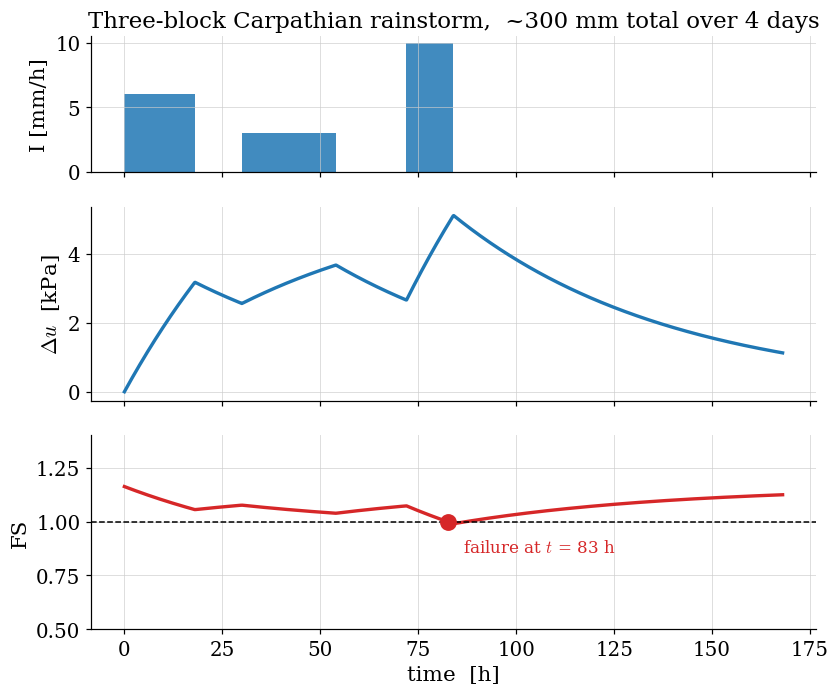

Cumulative rainfall: 300 mm
Minimum FS:          0.99
First failure at:    83 h


In [6]:
# Three sequential storm blocks
events = [
    dict(start=0.0,   duration=18.0, I=6.0),   # day 1: 6 mm/h for 18 h
    dict(start=30.0,  duration=24.0, I=3.0),   # day 2.5: drizzle for 24 h
    dict(start=72.0,  duration=12.0, I=10.0),  # day 4: short heavy burst
]

t_h = np.linspace(0, 168, 1200)
t_s = t_h * 3600.0
du_total = np.zeros_like(t_h)
intensity = np.zeros_like(t_h)

for ev in events:
    t_shift = (t_h - ev["start"]).clip(min=0) * 3600.0
    du_total += delta_u_response(
        t=t_shift,
        T_storm=ev["duration"] * 3600.0,
        z=2.0, beta_deg=28.0,
        I_mm_h=ev["I"], K_mm_h=8.0, D_m2_per_s=2e-5,
    )
    mask = (t_h >= ev["start"]) & (t_h <= ev["start"] + ev["duration"])
    intensity[mask] += ev["I"]

# FS time series
u0 = m0 * GAMMA_W * z * np.cos(np.radians(beta_deg))**2
m_t = (u0 + du_total) / (GAMMA_W * z * np.cos(np.radians(beta_deg))**2)
FS_t = np.array([fs_infinite_slope(beta_deg, z, c_prime, phi_deg, gamma, m) for m in m_t])

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.5, 7.0), sharex=True,
                                  gridspec_kw=dict(height_ratios=[0.7, 1.0, 1.0]))
a1.bar(t_h, intensity, width=t_h[1] - t_h[0], color=COLORS["water"], alpha=0.85)
a1.set_ylabel("I [mm/h]")
a1.set_title("Three-block Carpathian rainstorm,  ~300 mm total over 4 days")

a2.plot(t_h, du_total, color=COLORS["water"], lw=2.2)
a2.set_ylabel(r"$\Delta u$  [kPa]")

a3.plot(t_h, FS_t, color=COLORS["fail"], lw=2.2)
a3.axhline(1.0, color="black", lw=1.0, ls="--")
below = np.where(FS_t < 1.0)[0]
if below.size:
    t_fail = t_h[below[0]]
    a3.plot([t_fail], [1.0], "o", ms=10, color=COLORS["fail"])
    a3.annotate(fr"failure at $t$ = {t_fail:.0f} h",
                xy=(t_fail, 1.0), xytext=(10, -20),
                textcoords="offset points", color=COLORS["fail"], fontsize=11)
a3.set_xlabel("time  [h]")
a3.set_ylabel("FS")
a3.set_ylim(0.5, max(FS_t.max(), 1.4))
save_figure(fig, "carpathian_storm_event")
plt.show()

print(f"Cumulative rainfall: {sum(e['I']*e['duration'] for e in events):.0f} mm")
print(f"Minimum FS:          {FS_t.min():.2f}")
print(f"First failure at:    {t_h[below[0]]:.0f} h" if below.size else "Slope did not fail.")


## 7. Limitations and where to go from here

The exponential infiltration model in this notebook captures the qualitative response — delayed peak, slow drainage, superposition of events — but it is missing several things that matter in operational forecasting:

- **No surface-runoff threshold.** Real storms whose intensity exceeds $K_z$ generate runoff; only the infiltrating fraction $K_z$ ever reaches the slip surface. We cap the effective intensity at $K_z$, which is a crude approximation.
- **No unsaturated-zone physics.** Above the water table, suction and apparent cohesion dominate, and infiltration is a Richards-equation problem (van Genuchten retention curve). For deeper or drier columns this is non-negligible.
- **Single-layer soil.** Layered soils with conductivity contrasts (loess over till, weathered flysch over fresh) develop **perched water tables** that respond on much shorter timescales than equation (2) predicts.
- **Linearised diffusion.** The full Iverson (2000) treatment uses the proper error-function solution. Our exponential is within ~15 % at intermediate times.
- **Empirical ID thresholds need calibration.** A threshold imported from Italy will systematically misfire on Polish Carpathian slopes. For the Polish SOPO inventory, Tichavský et al. (2019) is the relevant local calibration.

For operational use, the next step is the open-source [TRIGRS](https://www.usgs.gov/software/trigrs-transient-rainfall-infiltration-and-grid-based-regional-slope-stability) model from the USGS (Baum et al., 2008), which solves the proper 1-D Richards-style infiltration over a DEM and is widely used in regional landslide early-warning.


## Take-aways

- Rainfall triggers slides on three time-scales — immediate (debris flows, shallow translational), sustained (days, the dominant Central-European mode), and delayed (deep-seated). The dominant time-scale is set by depth and diffusivity, $\tau \sim z^2/D$.
- The slope's pore-pressure response is delayed, peaks *after* the storm ends, and decays slowly. Failures often occur in the calm aftermath of a storm, not at peak intensity.
- Intensity–duration thresholds are the operational tool of choice. Regional thresholds (Tichavský et al. 2019 for the Carpathians) lie systematically lower than the global Caine (1980) line.
- For real forecasting, use a properly calibrated regional ID threshold paired with a regional landslide inventory. The infinite-slope plus exponential-infiltration model in this notebook is a teaching tool, not a forecasting tool.


## Voluntary exercises

1. Sketch the three rainfall-response time-scales for landslide triggering. For each, give a Central-European example of a landslide type that fits it.
2. Using equation (2), estimate the response time at depth $z = 1.0$ m and $z = 5.0$ m for a soil with $D = 2\times 10^{-5}$ m²/s. What does this tell you about *when* you would expect failure after the start of a 48 h storm?
3. A storm delivers a mean intensity of 5 mm/h for 24 h. Using the Caine (1980) and Tichavský et al. (2019) thresholds, predict whether shallow landslides are expected in (a) a hypothetical "global average" region and (b) the Polish Carpathians.
4. Why does FS often reach its minimum *after* a storm has ended, rather than during its most intense burst?


## References

- Caine, N. (1980). *The rainfall intensity–duration control of shallow landslides and debris flows.* Geografiska Annaler A, 62(1–2), 23–27.
- Iverson, R. M. (2000). *Landslide triggering by rain infiltration.* Water Resources Research, 36(7), 1897–1910.
- Wieczorek, G. F. & Glade, T. (2005). *Climatic factors influencing occurrence of debris flows.* In *Debris-Flow Hazards and Related Phenomena*, Springer, 325–362.
- Guzzetti, F., Peruccacci, S., Rossi, M., & Stark, C. P. (2008). *The rainfall intensity–duration control of shallow landslides and debris flows: an update.* Landslides, 5(1), 3–17.
- Baum, R. L., Savage, W. Z., & Godt, J. W. (2008). *TRIGRS — A Fortran program for transient rainfall infiltration and grid-based regional slope-stability analysis, version 2.0.* USGS Open-File Report 2008-1159.
- Tichavský, R., Ballesteros-Cánovas, J. A., Šilhán, K., Tolasz, R., & Stoffel, M. (2019). *Dry spells and extreme precipitation are the main trigger of landslides in Central Europe.* Scientific Reports, 9, 14560. https://doi.org/10.1038/s41598-019-51148-2
